# Customer Support Intent Classification using Machine Learning

**Dataset:** Banking77

**Goal:** Predict the intent of customer support messages using NLP and machine learning.

## 1. Import Dataset

In [36]:
import pandas as pd

train_df = pd.read_csv(r"C:\Users\acer\PycharmProjects\PythonProject4\data\train.csv")
test_df = pd.read_csv(r"C:\Users\acer\PycharmProjects\PythonProject4\data\test.csv")

train_df.head()

,text,label,label_text
0,I am still waiting on my card?,11,card_arrival
1,What can I do if my card still hasn't arrived ...,11,card_arrival
2,I have been waiting over a week. Is the card s...,11,card_arrival
3,Can I track my card while it is in the process...,11,card_arrival
4,"How do I know if I will get my card, or if it ...",11,card_arrival


## 2. Inspect the dataset

In [37]:
train_df.shape
train_df.info

<bound method DataFrame.info of                                                     text  label  \
0                         I am still waiting on my card?     11   
1      What can I do if my card still hasn't arrived ...     11   
2      I have been waiting over a week. Is the card s...     11   
3      Can I track my card while it is in the process...     11   
4      How do I know if I will get my card, or if it ...     11   
...                                                  ...    ...   
9998              You provide support in what countries?     24   
9999                  What countries are you supporting?     24   
10000                What countries are getting support?     24   
10001                     Are cards available in the EU?     24   
10002                   Which countries are represented?     24   

            label_text  
0         card_arrival  
1         card_arrival  
2         card_arrival  
3         card_arrival  
4         card_arrival  
...          

## 3. Check for null values

In [38]:
train_df.isnull().sum()

text          0
label         0
label_text    0
dtype: int64

## 4. Find unique intents

In [39]:
train_df['label'].nunique()

77

In [40]:
train_df['label_text'].value_counts().head(10)

label_text
card_payment_fee_charged                            187
direct_debit_payment_not_recognised                 182
balance_not_updated_after_cheque_or_cash_deposit    181
wrong_amount_of_cash_received                       180
cash_withdrawal_charge                              177
transaction_charged_twice                           175
declined_cash_withdrawal                            173
transfer_fee_charged                                172
transfer_not_received_by_recipient                  171
balance_not_updated_after_bank_transfer             171
Name: count, dtype: int64

## 5. Intent Distribution

In [42]:
train_df['text_length'] = train_df['text'].apply(len)
train_df['text_length'].describe()

count    10003.000000
mean        59.473758
std         40.867901
min         13.000000
25%         36.000000
50%         47.000000
75%         64.000000
max        433.000000
Name: text_length, dtype: float64

## 6. Visualisation

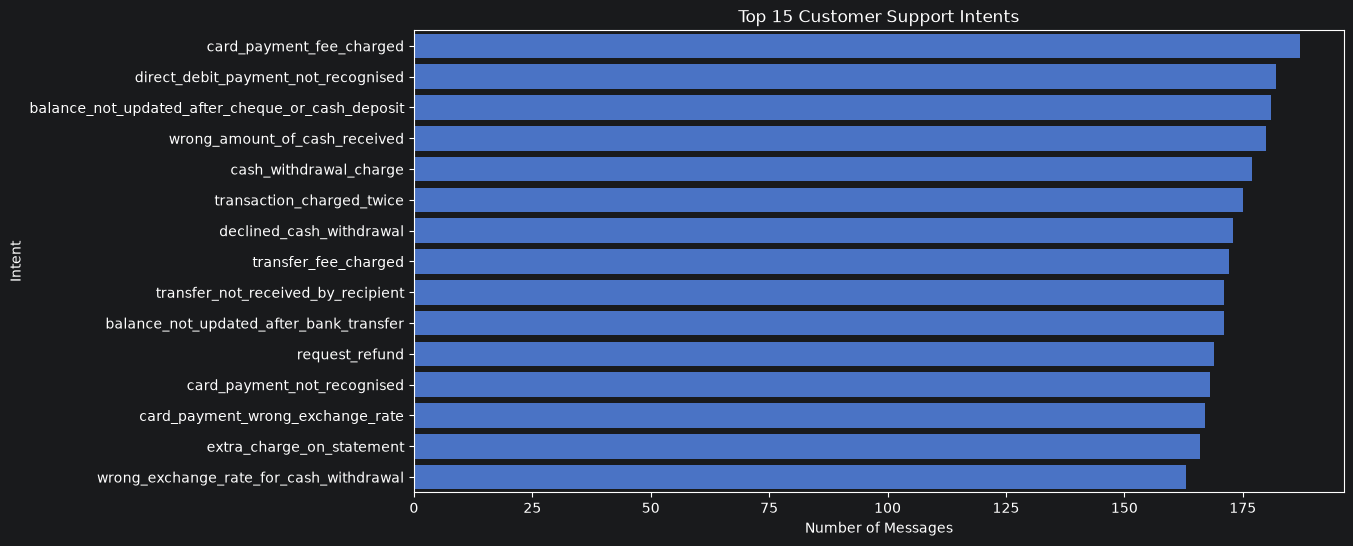

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,6))

sns.barplot(
    x=intent_counts.head(15).values,
    y=intent_counts.head(15).index
)

plt.title("Top 15 Customer Support Intents")
plt.xlabel("Number of Messages")
plt.ylabel("Intent")

plt.show()

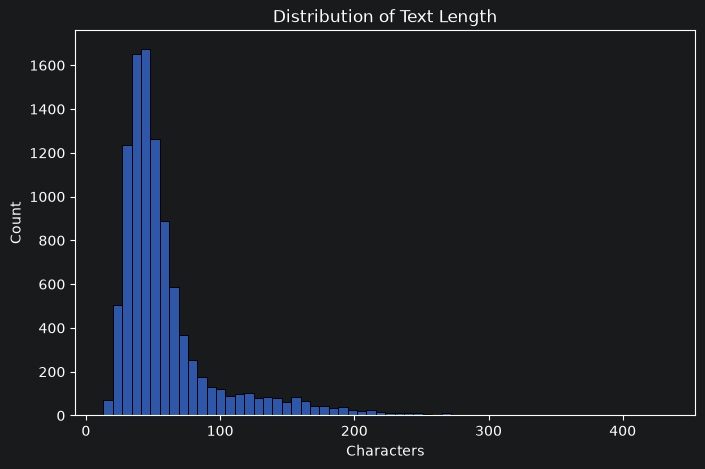

In [44]:
plt.figure(figsize=(8,5))

sns.histplot(
    train_df['text_length'],
    bins=60
)

plt.title("Distribution of Text Length")
plt.xlabel("Characters")
plt.show()

## 7. Creating copies

In [45]:
train=train_df.copy()
test=test_df.copy()

## 8. Text Cleaning

In [46]:
import re
def clean_text(text):
    text=text.lower()
    text=re.sub('[^a-zA-Z]',' ',text)
    return text

In [47]:
train['clean_text']=train['text'].apply(clean_text)
test['clean_text']=test['text'].apply(clean_text)

## 9. Feature and Target Selection

In [48]:
X_train=train['clean_text']
y_train=train['label_text']
X_test=test['clean_text']
y_test=test['label_text']

## 10. Feature Engineering using TF-IDF

In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(
    stop_words='english',
    max_features=5000,
)

In [50]:
X_train_tfidf=tfidf.fit_transform(X_train)
X_test_tfidf=tfidf.transform(X_test)


In [51]:
tfidf.get_feature_names_out()[:15]

array(['able', 'abroad', 'absolutely', 'accept', 'acceptable', 'accepted',
       'accepting', 'accepts', 'access', 'accessed', 'accessible',
       'accessing', 'accident', 'accidentally', 'accidently'],
      dtype=object)

In [52]:
import joblib
joblib.dump(tfidf,r'C:\Users\acer\PycharmProjects\PythonProject4\models\tfidf_vectorizer.pkl')

['C:\\Users\\acer\\PycharmProjects\\PythonProject4\\models\\tfidf_vectorizer.pkl']

## 11. Logistic Regression

In [53]:
from sklearn.linear_model import LogisticRegression
logreg=LogisticRegression(
    max_iter=1000,
    random_state=42,
   tol=1e-6
)
logreg.fit(X_train_tfidf,y_train)

,"tol tol: float, default=1e-4Tolerance for stopping criteria.",1e-06
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbf

In [54]:
y_pred=(logreg.predict(X_test_tfidf))

In [55]:
from sklearn.metrics import(
     accuracy_score,classification_report,confusion_matrix)
from sklearn.model_selection import cross_val_score

In [56]:
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)

0.8321428571428572


In [57]:
print(cross_val_score(logreg,X_train_tfidf,y_train,cv=5))

[0.82158921 0.81309345 0.8005997  0.804      0.8125    ]


## 12. Naive Bayes

In [58]:
from sklearn.naive_bayes import MultinomialNB
nb=MultinomialNB()
nb.fit(X_train_tfidf,y_train)
nb_pred=nb.predict(X_test_tfidf)
nb_accuracy=accuracy_score(y_test,nb_pred)
print(nb_accuracy)


0.7613636363636364


In [59]:
print(cross_val_score(nb,X_train_tfidf,y_train,cv=5))

[0.76561719 0.76211894 0.75812094 0.769      0.762     ]


## 13. LinearSVC

In [60]:
from sklearn.svm import LinearSVC
svm=LinearSVC(random_state=42,C=0.8)
svm.fit(X_train_tfidf,y_train)
svm.fit(X_train_tfidf,y_train)
svm_pred=svm.predict(X_test_tfidf)
svm_accuracy=accuracy_score(y_test,svm_pred)
print(svm_accuracy)

0.8516233766233766


In [61]:
print(cross_val_score(svm,X_train_tfidf,y_train,cv=5))

[0.82608696 0.82808596 0.82308846 0.823      0.8275    ]


In [62]:
print(confusion_matrix(y_test, svm_pred))

[[38  0  0 ...  0  0  0]
 [ 0 38  0 ...  0  0  0]
 [ 0  0 40 ...  0  0  0]
 ...
 [ 0  0  0 ... 30  0  0]
 [ 0  0  0 ...  0 35  0]
 [ 0  0  0 ...  0  1 33]]


In [63]:
print(classification_report(y_test, svm_pred))

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.81      0.95      0.87        40
                                activate_my_card       1.00      0.95      0.97        40
                                       age_limit       0.91      1.00      0.95        40
                         apple_pay_or_google_pay       0.97      0.97      0.97        40
                                     atm_support       0.90      0.95      0.93        40
                                automatic_top_up       0.95      0.95      0.95        40
         balance_not_updated_after_bank_transfer       0.71      0.75      0.73        40
balance_not_updated_after_cheque_or_cash_deposit       0.88      0.90      0.89        40
                         beneficiary_not_allowed       0.92      0.88      0.90        40
                                 cancel_transfer       0.93      0.97      0.95        40
         

## 14. Model Comparison

In [64]:
import pandas as pd
comparison=pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Multinomial Naive Bayes',
        'Linear SVM'

    ],
    'Accuracy':[
        accuracy,
        nb_accuracy,
        svm_accuracy

    ]
})
print(comparison)

                     Model  Accuracy
0      Logistic Regression  0.832143
1  Multinomial Naive Bayes  0.761364
2               Linear SVM  0.851623


## 15. Saving the model

In [65]:
import joblib

joblib.dump(svm, r"C:\Users\acer\PycharmProjects\PythonProject4\models\best_model.pkl")
joblib.dump(tfidf,r"C:\Users\acer\PycharmProjects\PythonProject4\models\tfidf_vectorizer.pkl")

['C:\\Users\\acer\\PycharmProjects\\PythonProject4\\models\\tfidf_vectorizer.pkl']